# 08. Estrategias de registro en la región frontal

Este notebook plantea una última mejora local y acotada sobre la región que ha mostrado mejor comportamiento (`front`).

Se comparan dos estrategias:
- `front + ICP directo`,
- `front + alineación global (FPFH + RANSAC) + ICP`.

El objetivo es analizar si una mejor inicialización del registro permite reducir el error sin modificar ni el modelo de depth ni la construcción de la pseudo-LiDAR.


In [1]:
from pathlib import Path
import json
import subprocess

import matplotlib.pyplot as plt


In [2]:
ROOT = Path('/home/clara/ml-depth-pro/slam_readiness_nuscenes')
RUN_SUMMARY = ROOT / 'outputs' / 'scene-0061' / 'run_summary.json'
SCRIPT_PATH = ROOT / 'scripts' / 'compare_front_registration_strategies.py'


## Hipótesis de trabajo

Si la inicialización global resulta útil, la estrategia `front_global_then_icp` debería mejorar al menos en:
- error de traslación,
- error de rotación.

Si no se observa mejora, podrá concluirse que el cuello de botella no se encuentra en la inicialización del registro, sino en la calidad geométrica de la pseudo-LiDAR frontal.


In [3]:
cmd = [
    'python',
    str(SCRIPT_PATH),
    '--run-summary', str(RUN_SUMMARY),
    '--dataroot', '/home/clara/datasets/nuscenes',
    '--version', 'v1.0-mini',
]
print(' '.join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
print(result.stderr)
print('returncode:', result.returncode)


python /home/clara/ml-depth-pro/slam_readiness_nuscenes/scripts/compare_front_registration_strategies.py --run-summary /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/run_summary.json --dataroot /home/clara/datasets/nuscenes --version v1.0-mini
/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/front_registration_strategies.json
{
  "front_icp_only_translation_error_mean_m": 1.9059026777944303,
  "front_icp_only_rotation_error_mean_deg": 2.3303987058296873,
  "front_icp_only_fitness_mean": 0.7518827944175293,
  "front_global_then_icp_translation_error_mean_m": 5.860979562688913,
  "front_global_then_icp_rotation_error_mean_deg": 24.471165499696102,
  "front_global_then_icp_fitness_mean": 0.7309622935977695
}


returncode: 0


In [4]:
results_path = ROOT / 'outputs' / 'scene-0061' / 'front_registration_strategies.json'
results = json.loads(results_path.read_text())
results['aggregate']


{'front_icp_only_translation_error_mean_m': 1.9059026777944303,
 'front_icp_only_rotation_error_mean_deg': 2.3303987058296873,
 'front_icp_only_fitness_mean': 0.7518827944175293,
 'front_global_then_icp_translation_error_mean_m': 5.860979562688913,
 'front_global_then_icp_rotation_error_mean_deg': 24.471165499696102,
 'front_global_then_icp_fitness_mean': 0.7309622935977695}

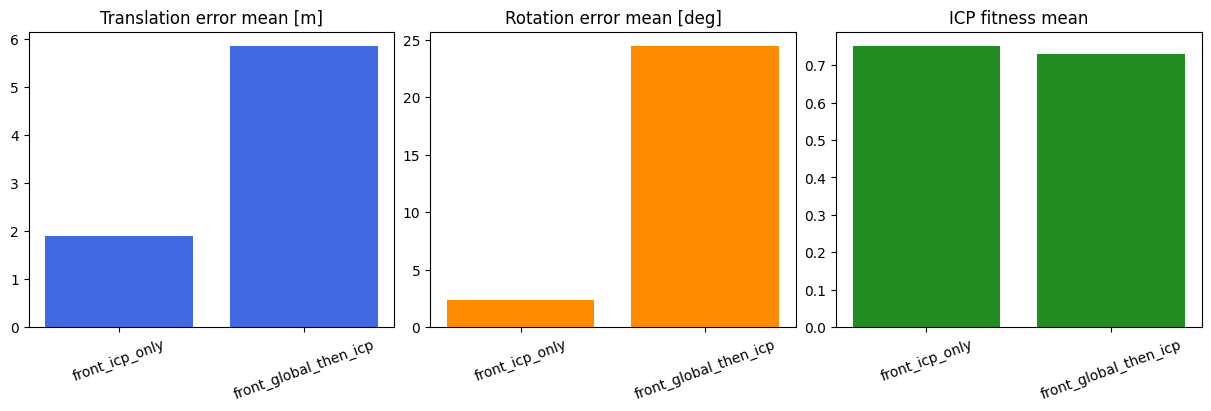

In [5]:
labels = ['front_icp_only', 'front_global_then_icp']
trans = [results['aggregate']['front_icp_only_translation_error_mean_m'], results['aggregate']['front_global_then_icp_translation_error_mean_m']]
rot = [results['aggregate']['front_icp_only_rotation_error_mean_deg'], results['aggregate']['front_global_then_icp_rotation_error_mean_deg']]
fitness = [results['aggregate']['front_icp_only_fitness_mean'], results['aggregate']['front_global_then_icp_fitness_mean']]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
axes[0].bar(labels, trans, color='royalblue')
axes[0].set_title('Translation error mean [m]')
axes[1].bar(labels, rot, color='darkorange')
axes[1].set_title('Rotation error mean [deg]')
axes[2].bar(labels, fitness, color='forestgreen')
axes[2].set_title('ICP fitness mean')

for ax in axes:
    ax.tick_params(axis='x', rotation=20)

plt.show()


## Criterio para decidir

- Si `front_global_then_icp` mejora, entonces seguirá existiendo margen de reducción del error actuando sobre el propio registro.
- Si no mejora, la conclusión razonable será que el límite principal ya viene impuesto por la calidad geométrica de la pseudo-LiDAR frontal.
